In [15]:
import tpqoa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timezone, timedelta
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [16]:
class BollTrader(tpqoa.tpqoa):
    def __init__(self, conf_file, instrument, bar_length, SMA, dev, units):
        super().__init__(conf_file)
        self.instrument=instrument
        self.bar_length=pd.to_timedelta(bar_length)
        self.tick_data=pd.DataFrame()
        self.raw_data=None
        self.data=None
        self.last_bar=None
        self.units=units
        self.position=0
        self.profits=[]
        self.snapshots = []
        #*****************add strategy-specific attributes here******************
        self.SMA=SMA
        self.dev=dev
        #************************************************************************
    #**********Tage den Bar-Längen-Parameter anpassen**** bei 1s 1 Tag/ 1min 5 Tage*******
    def get_most_recent(self,days=1):
        while True:
            time.sleep(2)
            now=datetime.now(timezone.utc).replace(tzinfo=None)
            now=now-timedelta(microseconds=now.microsecond)
            past=now-timedelta(days=days)
            df=self.get_history(instrument=self.instrument,start=past,end=now,
                                granularity='S5',price='M',
                                localize=False).c.dropna().to_frame()
            df.rename(columns={'c':self.instrument},inplace=True)
            df=df.resample(self.bar_length,label='right').last().dropna().iloc[:-1]
            self.raw_data=df.copy()
            self.last_bar=self.raw_data.index[-1]

            if pd.to_datetime(datetime.now(timezone.utc))-self.last_bar<self.bar_length:
                break

    def on_success(self,time,bid,ask):
        print(self.ticks,end='')

        recent_tick=pd.to_datetime(time)
        df=pd.DataFrame({self.instrument:(ask+bid)/2},index=[recent_tick])
        self.tick_data=pd.concat([self.tick_data,df])

        if recent_tick-self.last_bar>self.bar_length:
            self.resample_and_join()
            self.define_strategy()
            self.excecute_trades()

    def resample_and_join(self):
        self.raw_data=pd.concat([self.raw_data,
                                 self.tick_data.resample(self.bar_length,
                                 label='right').last().ffill().iloc[:-1]])
        self.tick_data=self.tick_data.iloc[:-1]
        self.last_bar=self.raw_data.index[-1]

    def define_strategy(self):
        df=self.raw_data.copy()


        #*****************define your strategy here******************
        df['SMA']=df[self.instrument].rolling(self.SMA).mean()
        df['Lower']=df['SMA']-df[self.instrument].rolling(self.SMA).std()*self.dev
        df['Upper']=df['SMA']+df[self.instrument].rolling(self.SMA).std()*self.dev
        df['distance']=df[self.instrument]-df.SMA
        df['position']=np.where(df[self.instrument]<df.Lower,1,np.nan)
        df['position']=np.where(df[self.instrument]>df.Upper,-1,df['position'])
        df['position']=np.where(df.distance*df.distance.shift(1)<0,0,df['position'])
        df['position']=df.position.ffill().fillna(0)
        #************************************************************************

        self.data=df.copy()
        # self.snapshots.append(self.data.copy())

    def excecute_trades(self):
        if self.data['position'].iloc[-1]==1:
            if self.position==0:
                order=self.create_order(self.instrument,self.units,suppress=True,ret=True)
                self.report_trade(order, 'going long')
            elif self.position==-1:
                order=self.create_order(self.instrument,self.units*2,suppress=True,ret=True)
                self.report_trade(order, 'going long')
            self.position=1
        elif self.data['position'].iloc[-1]==-1:
            if self.position==0:
                order=self.create_order(self.instrument,-self.units,suppress=True,ret=True)
                self.report_trade(order, 'going short')
            elif self.position==1:
                order=self.create_order(self.instrument,-self.units*2,suppress=True,ret=True)
                self.report_trade(order, 'going short')
            self.position=-1
        elif self.data['position'].iloc[-1]==0:
            if self.position==-1:
                order=self.create_order(self.instrument,self.units,suppress=True,ret=True)
                self.report_trade(order, 'going neutral')
            elif self.position==1:
                order=self.create_order(self.instrument,-self.units,suppress=True,ret=True)
                self.report_trade(order,'going neutral')
            self.position=0

    def report_trade(self,order,going):
        time=order['time']
        units=order['units']
        price=order['price']
        pl=float(order['pl'])
        self.profits.append(pl)
        cumpl=sum(self.profits)
        print('\n'+100*'-')
        print(f'{time} | {going}')
        print(f'{time} | units={units} | price={price} | P&L={pl} | Cum P&L={cumpl}')
        print(100*'-'+'\n')


In [17]:
trader=BollTrader(r'C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Trading\Data\oanda.cfg','EUR_USD','5s',SMA=20,dev=2,units=10000)

# Default values: SMA=20,dev=1,units=100000)

In [18]:
trader.get_most_recent()
trader.stream_data(trader.instrument,stop=250)
if trader.position!=0: #if we have a final position
    close_order=trader.create_order(trader.instrument,units=-trader.position*trader.units,suppress=True,ret=True)
    trader.report_trade(close_order,'going neutral')
    trader.position=0

12
----------------------------------------------------------------------------------------------------
2025-12-12T09:29:41.107907558Z | going short
2025-12-12T09:29:41.107907558Z | units=-10000.0 | price=1.17297 | P&L=0.0 | Cum P&L=0.0
----------------------------------------------------------------------------------------------------

345678910111213141516
----------------------------------------------------------------------------------------------------
2025-12-12T09:29:55.403989422Z | going neutral
2025-12-12T09:29:55.403989422Z | units=10000.0 | price=1.17307 | P&L=-0.8568 | Cum P&L=-0.8568
----------------------------------------------------------------------------------------------------

17181920212223242526272829303132333435
----------------------------------------------------------------------------------------------------
2025-12-12T09:30:10.573887886Z | going long
2025-12-12T09:30:10.573887886Z | units=10000.0 | price=1.17302 | P&L=0.0 | Cum P&L=-0.8568
-------------------

In [5]:
# snap = trader.snapshots[-1]
# snap.tail()


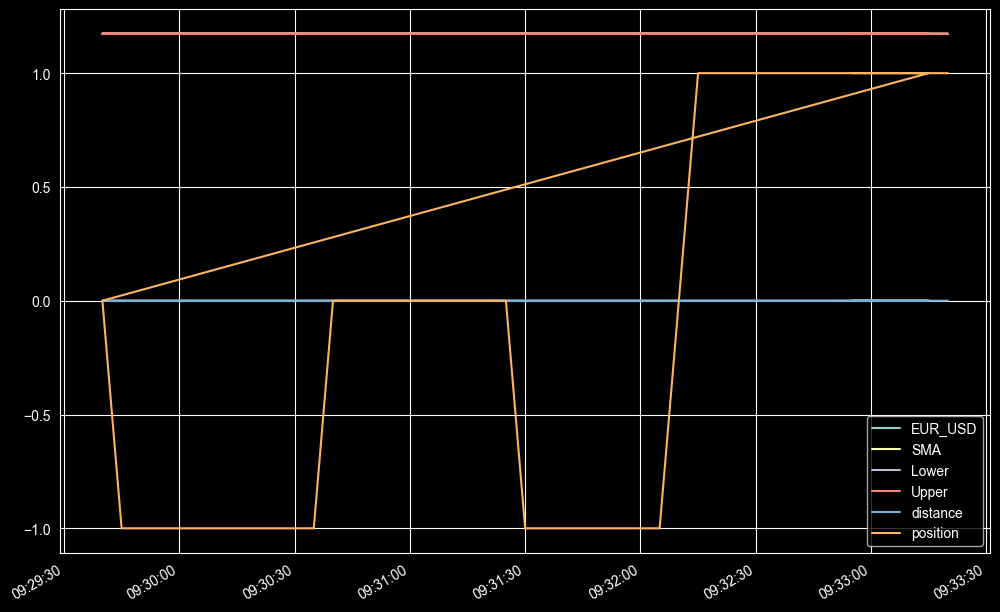

In [23]:
trader.data.tail(50).plot(figsize = (12, 8))
plt.show()